# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 4. Создаем GPT-0.001 в <s>гаражных</s> общажных условиях.


**Правила, <font color="red">прочитайте внимательно</font>:**

1. Общее

     * Выполненную работу **в формате `ipynb`** нужно отправить по ссылке "Сдача ДЗ" на <a href="https://thetahat.ru/courses/ad"><b>странице курса</b></a>. **Работы, присланные иным способом, не принимаются.** Дедлайны указаны в боте и на сайте, они являются строгими.
     
     * Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><b>руководство по оформлению ДЗ</b></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.
     
     * Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
     
     * Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф -3 скор-балла к итоговой оценке.**
     
     * Решение теоретических задач оформляйте в markdown-ячейках формате $\LaTeX$. При решении можно использовать ИИ-инструменты только для оформления написанного самостоятельно решения. Например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.
     
     * Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
     </br>

2. Правила заполнения ноутбука

     * Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.
     * Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены `<...>`.
     * Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках.
     * Условия <font color="red"><b>запрещается модифицировать</b></font>.
     * При нарушении данных правил работа может получить 0 баллов.
</br>


**Баллы за задание**

* Задача 1 &mdash; 40 баллов;
* Задача 2 &mdash; 60 баллов.

In [181]:
import json
import os
import re
import urllib.request
from collections import Counter
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from navec import Navec
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import SGDClassifier
from tqdm.notebook import tqdm

sns.set_theme(style="whitegrid", palette="Set2")

In [4]:
# Bot check

# HW_ID: fpmi_ad4
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. [ссылка](https://chatgpt.com/share/69b5525e-1be8-8008-9333-1cbbb7fbbe6f)
    - Описание SGDClassifyier


---

На лекции мы обсуждали, как работают современные языковые модели (LLM) наподобие ChatGPT: они используют архитектуру Transformer, механизм внимания (Self-Attention) и предсказывают следующий токен. Звучит как магия из мира бигтеха, правда?

Конечно, пока вы не знаете, как математически писать и обучать глубокие нейронные сети. Но знаете что? Чтобы построить **нашу собственную GPT-0.001** прямо здесь, на ваших ноутбуках в корридорах ваших общаг, вам это и не нужно! 

Фундаментальные принципы современных моделей можно понять и воспроизвести с помощью базовых инструментов, которые вы уже знаете:
* логистическая регрессия послужит нам финальным слоем предсказания,
* для представления текста в виде векторов будем использовать One-Hot преобразование,
* а понять смыслы слов на поможет старый добрый KNN!

В этом задании мы с вами шаг за шагом пройдем путь от простейшего генератора текста (символьной модели) до создания собственного механизма динамического внимания (Attention). Поехали!

---
### Задача 1.

#### 1. Данные: на чем будем учить?

Скачайте файл: [all_django.json](https://github.com/IlyaGusev/PoetryCorpus/blob/master/datasets/django/all_django.json) — это корпус стихов русских поэтов.

**Почему именно стихи?**
Обучать языковую модель с нуля на Википедии — задача для суперкомпьютеров. Наша общажная модель с таким не справится (у нас просто не хватит оперативной памяти и времени). А вот стихи — это идеальная "игрушечная вселенная" для языковой модели по нескольким причинам:
* В стихах есть рифма и ритм. Вероятность появления определенных слов или окончаний в конце строки сильно выше.
* Поэты часто используют устойчивые эпитеты («мороз и солнце», «буря мглою», «парус одинокий»). Модели будет проще выучить эти локальные зависимости.
* Лексика поэтов (особенно классиков) пересекается, что сильно упрощает задачу классификации для нашей логистической регрессии.

*Замечание.*  На самом деле не стоит думать, что стихи — это «просто». В реальности поэзия — одна из самых сложных доменных областей: омографы, где смысл и ударение зависят от контекста, инверсии, авторская пунктуация, метафоры с неочевидными семантическими связями. Полноценная генерация стихов с правильным размером и осмысленным содержанием — до сих пор не до конца решенная задача.

Давайте загрузим датасет и посмотрим на него.

In [117]:
with open("all_django.json", "r", encoding="utf-8") as f:
    all_poems = json.load(f)

data = []
for poem in all_poems:
    data.append(
        {
            "author": poem["fields"]["author"],
            "text": poem["fields"]["text"],
        }
    )

data = pd.DataFrame(data)
data["length"] = data["text"].str.len()  # количество символов
data.head()

,author,text,length
0,Михаил Лермонтов,"Забывши волнения жизни мятежной,\nОдин жил в п...",193
1,Сергей Есенин,"Нивы сжаты, рощи голы,\nОт воды туман и сырост...",291
2,Игорь Северянин,Лючинь печальная читала вечером ручьисто-вкрад...,611
3,Анатолий Жигулин,"Глыбу кварца разбили молотом,\nИ, веселым огне...",745
4,Николай Тихонов,"Хлынул дождь, когда девушки, встав в хоровод,\...",532


В данных представлено довольно много стихов

In [118]:
len(data)

16694

Посмотрим на один случайный стих

In [119]:
random_poem_index = np.random.choice(range(len(data)))
print(data.iloc[random_poem_index, 1])

Солнце, солнце,
божественный Ра-Гелиос,
тобою веселятся
сердца царей и героев,
тебе ржут священные кони,
тебе поют гимны в Гелиополе;
когда ты светишь,
ящерицы выползают на камни
и мальчики идут со смехом
купаться к Нилу.
Солнце, солнце,
я — бледный писец,
библиотечный затворник,
но я люблю тебя, солнце, не меньше,
чем загорелый моряк,
пахнущий рыбой и соленой водою,
и не меньше,
чем его привычное сердце
ликует
при царственном твоем восходе
из океана,
мое трепещет,
когда твой пыльный, но пламенный луч
скользнет
сквозь узкое окно у потолка
на исписанный лист
и мою тонкую желтоватую руку,
выводящую киноварью
первую букву гимна тебе,
о Ра-Гелиос солнце!


Проведите базовый разведочный анализ данных.
* Определите топ-10 писателей по количеству стихов.
* Постройте гистограмму длины стихов (по количеству символов).
* Определите, какой стих самый длинный.

In [120]:
print('10 самых популярных авторов и количество их стихов:')
print(data.groupby('author').count()['text'].sort_values(ascending=False).head(10))

10 самых популярных авторов и количество их стихов:
author
Владимир Высоцкий    539
Александр Пушкин     401
Александр Блок       286
Анна Ахматова        277
Афанасий Фет         251
Федор Тютчев         242
Илья Эренбург        237
Михаил Лермонтов     234
Федор Сологуб        230
Валерий Брюсов       211
Name: text, dtype: int64


Самый длинный стих:


,author,text,length
8027,Николай Некрасов,Посвящаю моей сестре\nАнне Алексеевне.\nТы опя...,28243


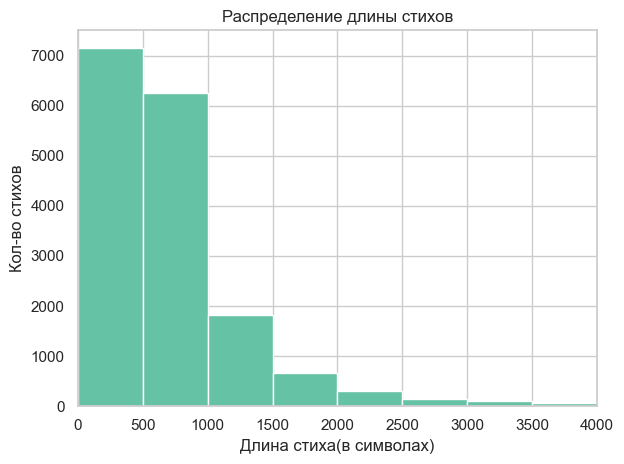

In [121]:
plt.hist(data['length'], bins=np.arange(0, 4001, 500))
plt.xlim(0, 4000)
plt.title('Распределение длины стихов')
plt.xlabel('Длина стиха(в символах)')
plt.ylabel('Кол-во стихов')
plt.tight_layout() # Построение гистограммы

print('Самый длинный стих:')
data.sort_values('length', ascending=False).head(1)

Поскольку мы создаем самую простую модель (да еще и на CPU ваших компьютеров), нам нужно максимально облегчить ей жизнь. Любая пунктуация, заглавные буквы и переносы строк — это "лишний шум", на распознавание которого модели придется тратить свои силы. 

Поэтому мы проведем жесткую предобработку

In [122]:
# Переводим в нижний регистр
data["text"] = data["text"].str.lower()
# Заменяем переносы строк на пробелы
data["text"] = data["text"].str.replace("\n", " ", regex=False)
# Оставляем только буквы и пробелы
data["text"] = data["text"].str.replace(r"[^а-яё\s]", "", regex=True)
# Убираем множественные пробелы
data["text"] = data["text"].str.replace(r"\s+", " ", regex=True).str.strip()

Посмотрим, как теперь выглядит стих. Он превратился в непрерывный поток слов

In [123]:
print(data.iloc[random_poem_index, 1])

солнце солнце божественный рагелиос тобою веселятся сердца царей и героев тебе ржут священные кони тебе поют гимны в гелиополе когда ты светишь ящерицы выползают на камни и мальчики идут со смехом купаться к нилу солнце солнце я бледный писец библиотечный затворник но я люблю тебя солнце не меньше чем загорелый моряк пахнущий рыбой и соленой водою и не меньше чем его привычное сердце ликует при царственном твоем восходе из океана мое трепещет когда твой пыльный но пламенный луч скользнет сквозь узкое окно у потолка на исписанный лист и мою тонкую желтоватую руку выводящую киноварью первую букву гимна тебе о рагелиос солнце


Всего количества стихов для дальнейшего анализа может оказаться много. Чтобы матрица признаков не взорвала вашу оперативную память, а модели успели обучиться до дедлайна, ограничим выборку. 

Вы можете взять больше или меньше, но не менее 1000.

*Совет:* для отладки кода (чтобы ячейки выполнялись быстро) берите `max_poems_count = 100`, а когда убедитесь, что всё работает — увеличьте это число и перезапустите ноутбук, чтобы получить более умную модель и сделать содержательные выводы.

In [133]:
max_poems_count = 5000
data_sample = data.sample(max_poems_count)

#### 2. Символьная языковая модель &mdash; простейший аналог GPT

Суть любой языковой модели (даже самой мощной) сводится к одной простой задаче — **предсказать следующий токен** на основе предыдущих. Давайте для начала в качестве "токенов" возьмем отдельные символы (буквы). Обучим нашу простую логистическую регрессию делать это предсказание!

Для формирования обучающей выборки воспользуется методом "скользящего окна". Пусть размер нашего окна (контекста) будет равен 5 символам. Мы будем двигать это окно по тексту: 5 символов идут в признаки, а 6-й символ становится нашей целевой переменной. 

> **Пример для фразы "мороз и солнце" и окна = 5:**
> * $X_1 = $ `['м', 'о', 'р', 'о', 'з']`, $Y_1 = $ `' '` (пробел)
> * $X_2 = $ `['о', 'р', 'о', 'з', ' ']`, $Y_2 = $ `'и'`
> * $X_3 = $ `['р', 'о', 'з', ' ', 'и']`, $Y_3 = $ `' '` (пробел)
> * и так далее...


*Замечание.* По сути мы сейчас строим классическую $N$-граммную модель — одну из старейших идей в области обработки естественного языка. В нашем случае – это 6-граммная на уровне символов. Можно было бы обойтись и без логистической регрессии: просто посчитать, как часто после комбинации `['о', 'р', 'о', 'з', ' ']` встречается каждый символ, и превратить частоты в оценку вероятности. Это и есть статистическая n-граммная модель. Однако, используя логистическую регрессию, наша модель сможет обобщаться на комбинации символов, которых она ни разу не видела в обучающей выборке.

Сформируйте массивы `X_raw` &mdash; списки из 5 символов и `y_raw` &mdash; следующий символ.

In [162]:
window_size = 5  # Количество символов в истории

X_raw = []
y_raw = []

# Перебираем случайные max_poems_count стихов
for text in tqdm(data_sample["text"]):

    # Проверка на случай, если после очистки текст стал короче окна
    if len(text) <= window_size:
        continue

    # Создаем массив списков длины window_size и следующего символа
    for i in range(0, len(text) - window_size):
        X_raw.append(list(text[i:i + window_size]))
        y_raw.append(text[i + window_size])

  0%|          | 0/5000 [00:00<?, ?it/s]

Посмотрим, сколько всего получилось комбинаций и как выглядят несколько первых

In [163]:
print(f"Размер выборки: {len(X_raw)}")
for x, y in zip(X_raw[:20], y_raw[:20]):
    print(x, y)

Размер выборки: 3646803
['б', 'р', 'а', 'т', 'а'] й
['р', 'а', 'т', 'а', 'й'] т
['а', 'т', 'а', 'й', 'т'] е
['т', 'а', 'й', 'т', 'е'] с
['а', 'й', 'т', 'е', 'с'] я
['й', 'т', 'е', 'с', 'я']  
['т', 'е', 'с', 'я', ' '] к
['е', 'с', 'я', ' ', 'к']  
['с', 'я', ' ', 'к', ' '] в
['я', ' ', 'к', ' ', 'в'] з
[' ', 'к', ' ', 'в', 'з'] а
['к', ' ', 'в', 'з', 'а'] и
[' ', 'в', 'з', 'а', 'и'] м
['в', 'з', 'а', 'и', 'м'] н
['з', 'а', 'и', 'м', 'н'] о
['а', 'и', 'м', 'н', 'о'] й
['и', 'м', 'н', 'о', 'й']  
['м', 'н', 'о', 'й', ' '] о
['н', 'о', 'й', ' ', 'о'] б
['о', 'й', ' ', 'о', 'б'] о


Соберем словарь всех уникальных символов, которые встретились в `y_raw`. Эти символы станут **классами**, которые будет предсказывать наша логистическая регрессия.

In [164]:
chars = sorted(list(set(y_raw)))
char_to_idx = {c: i for i, c in enumerate(chars)}
idx_to_char = {i: c for i, c in enumerate(chars)}
n_chars = len(chars)

print(f"Всего уникальных символов: {n_chars}")

Всего уникальных символов: 34


Преобразуйте `X_raw` в числовую матрицу признаков с помощью знакомого вам **One-Hot Encoding**. 

In [165]:
encoder = OneHotEncoder(handle_unknown='ignore') # Создание энкодера и энкодинг
X = encoder.fit_transform(X_raw)

y = np.array([char_to_idx[c] for c in y_raw])

Сколько всего получилось признаков? Почему их столько много?

In [166]:
print(f'Кол-во признаков: {X.shape[1]}')


Кол-во признаков: 170


Потому что 5 позиций и на каждой по 34 символа может быть, итого 170 признаков

Отлично! У нас есть матрица признаков $X$ и вектор ответов $y$. 

Обучите логистическую регрессию. Поскольку данных и классов много, возможно, потребуется увеличить количество итераций обучения модели. Также может помочь замена на `SGDClassifier` с параметром `loss='log_loss'`, это та же логистическая регрессия.

In [167]:
model = SGDClassifier(loss='log_loss', max_iter=500000)
model.fit(X, y)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",500000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


Бинго! Наша нейросеть, состоящая ровно из одного линейного слоя, обучена. Да да, нейросеть!

При генерации текста в современных LLM часто используют параметр **температуры**. Он управляет "креативностью" модели. Если всегда выбирать строго символ с максимальной вероятностью, модель будет зацикливаться и выдавать скучный, повторяющийся текст. Температура позволяет нам сэмплировать следующий символ, хитро меняя распределение вероятностей.

> **Принцип работы:**
> 
> Наша регрессия выдает "сырые" уверенности модели — логиты ($\ell_k$). Чтобы получить оценки вероятностей $P_k$, в многоклассовой логистической регрессии мы применяем функцию Softmax:
> 
> $$P_k = \frac{\exp\left({\ell_k}\right)}{\sum_{j} \exp\left({\ell_j}\right)}$$
> 
> Температура $T$ просто делит логиты перед экспонентой:
> 
> $$P'_k = \frac{\exp\left({\left.\ell_k \right/ T}\right)}{\sum_{j}\exp\left({\left.\ell_j \right/ T}\right)}$$
> На основе этого мы получаем новое распределение вероятностей, из которого будет производиться сэмплирование. 

Опираясь на эту формулу, поясните своими словами, как будет вести себя модель (насколько случайным будет выбор) при следующих значениях $T$:
* $T \approx 0$
* $0 < T < 1$
* $T = 1$
* $T > 1$

* При $T \approx 0$ все вероятности, кроме самой большой будут нулевые, с самым большим логитом будет вероятность почти 1. Если максимумов несколько, вероятность делится между ними.
* При $0 < T < 1$ вероятность будет завышать вероятности классов с самым большим логитом и занижать остальные
* При $T = 1$ стандартный softmax
* При $T > 1$ будет увеличивать вероятность классов с маньшим логитом и при этом занижать вероятность наибольших логитов, делает распределение более равномерным
  

Пришло время заставить нашу модель говорить! Напишите функцию генерации текста. 

Вам нужно:
1. Взять последние 5 символов текста.
2. Преобразовать их через one hot энкодер.
3. Получить предсказания вероятностей из логистической регрессии.
4. Применить температуру к полученным вероятностям (по формуле выше).
5. Сделать случайный выбор символа с помощью `np.random.choice`.

In [172]:
def generate_text(model: Any, start_text: str, length: int = 60, temperature: float = 1.0) -> str:
    """Генерирует текст посимвольно на основе обученной модели.
    :param model: Обученная модель классификации (например, SGDClassifier).
    :param start_text: Начальная строка, с которой начнется генерация.
    :param length: Количество символов для генерации.
    :param temperature: Температура сэмплирования (управляет случайностью выбора).
    :return: Сгенерированная строка текста."""
    current_text = start_text.lower()

    for _ in range(length):
        context = list(current_text[-window_size:])
        # Если контекст меньше окна, дополним пробелами
        while len(context) < window_size:
            context.insert(0, " ")

        context_enc = encoder.transform(np.array(context).reshape(1, -1))

        # Получите предсказание вероятностей
        probabilities = model.predict_proba(context_enc)

        # Примените температуру

        proba_t = (probabilities ** (1 / temperature) / np.sum(probabilities ** (1 / temperature)))[0]

        # Сгенерируйте следующий символ и добавьте его к тексту.
        symb = idx_to_char[np.random.choice(range(n_chars), p=proba_t)]

        current_text += symb

    return current_text

Давайте потестируем нашего Франкенштейна! Запустим генерацию с разными стартовыми фразами и разными значениями температуры.

In [174]:
temperature_list = [0.1, 0.8, 1.5]
text_list = [
    "мороз и сол",
    "буря мгл",
]

for text in text_list:
    for temperature in temperature_list:
        generated_text = generate_text(model, text, temperature=temperature)
        print(f"Температура {temperature}: {generated_text}")

Температура 0.1: мороз и соло на порада сто на порада столи не воросто на пола не сто на
Температура 0.8: мороз и солет в ногупорит раг васхужатной далеет на о дел валил в обоет
Температура 1.5: мороз и солышд чжитне о исмыл чйстоюёдъгомусе быжяес кана гонц дыпу дям
Температура 0.1: буря мгла но поста не породно вором не столи на сто на порада стол н
Температура 0.8: буря мглад ною уждинь остралита калешь поспилаков л огрубедты кваего
Температура 1.5: буря мгли рапчюейужет нисгугдаколю тжелваети ясечиютспъйлыъапотоётео


Посмотрите на сгенерированные тексты. Похоже ли это на русский язык? Появляются ли осмысленные слова? Как влияет температура на результат?

Это не похоже на русский язык, но появляются отдельные осмысленные слова. Смысла хоть какого-то пока нет
При большей температуре увеличивается средняя длина слова и соответственно пропадают осмысленные слова

#### 3. Заглядываем внутрь модели

Модель как-то научилась собирать буквы в слоги, похожие на русские. Но как она принимает решения? На какую из 5 позиций в нашем контекстном "окне" она смотрит больше всего? 

Для начала вспомните, что означают коэффициенты модели, если все признаки находятся в одном масштабе (у нас все признаки бинарные)?

Показывает, какие признаки сильнее увеличивают вероятность конкретного класса. Т. е. чем больше коэфицент, тем сильнее увеличивается score, а значит и вероятность класса. Аналогично в другую сторону

Посмотрим на количество коэффициентов модели

In [175]:
model.coef_.shape

(34, 170)

Давайте визуализируем важности для конкретного предсказываемого символа (например, для буквы "я").

In [176]:
target_char = "я"

# Извлеките коэффициенты для target_char и приведите к нужному размеру
influence = model.coef_[char_to_idx[target_char]].reshape(window_size, n_chars)
assert influence.shape == (window_size, n_chars)

Нарисуем тепловую карту, где красный цвет означает положительный вес, синий — отрицательный.

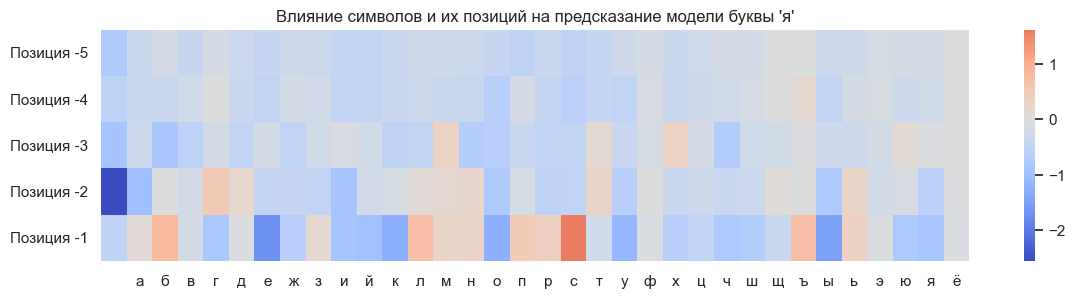

In [177]:
plt.figure(figsize=(14, 3))
sns.heatmap(
    influence,
    xticklabels=chars,
    yticklabels=[f"Позиция -{window_size-i}" for i in range(window_size)],
    cmap="coolwarm",
    center=0,
)
plt.title(f"Влияние символов и их позиций на предсказание модели буквы '{target_char}'")
plt.show()

Посмотрите также аналогичные графики для нескольких других символов.

In [183]:
def check_influence(symb: str):
    influence = model.coef_[char_to_idx[symb]].reshape(window_size, n_chars)
    plt.figure(figsize=(14, 3))
    sns.heatmap(
        influence,
        xticklabels=chars,
        yticklabels=[f"Позиция -{window_size-i}" for i in range(window_size)],
        cmap="coolwarm",
        center=0,
    )
    plt.title(f"Влияние символов и их позиций на предсказание модели буквы '{symb}'")
    plt.show()

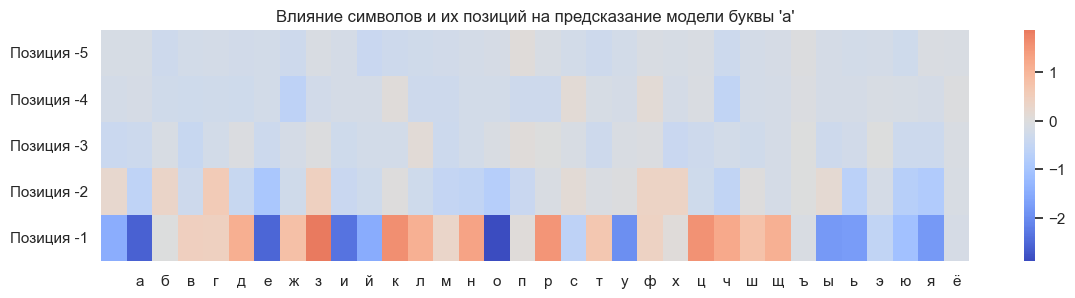

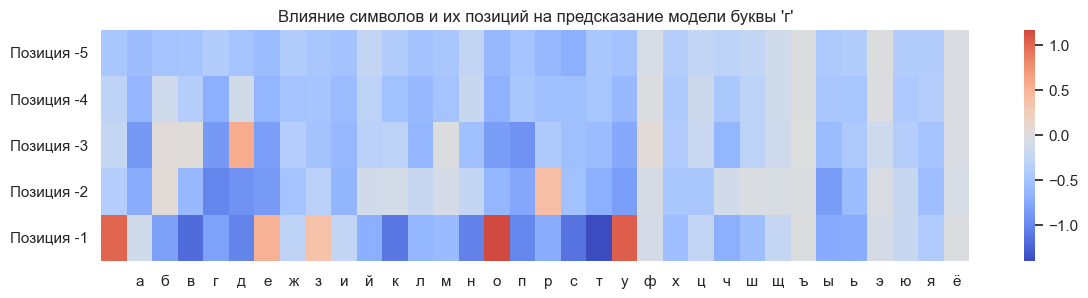

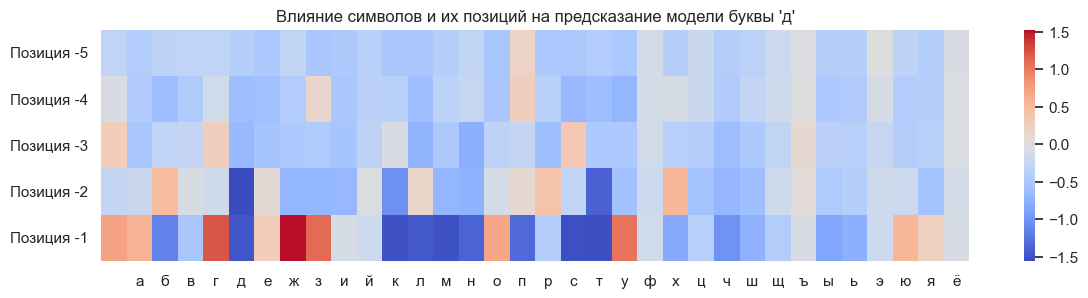

In [188]:
check_influence('а')
check_influence('г')
check_influence('д')

Можно ли увидеть какие-то закономерности? Какие позиции влияют сильнее всего?

Явна видна закономерность, что ближайщая позиция к прогнозируемой букве намного больше влияет, чем самая дальняя

Постройте "карту общей важности позиций". Для каждой из 5 позиций в окне посчитайте суммарный абсолютный вес (по модулю) по всем символам и всем классам, отобразите их в виде bar plot.

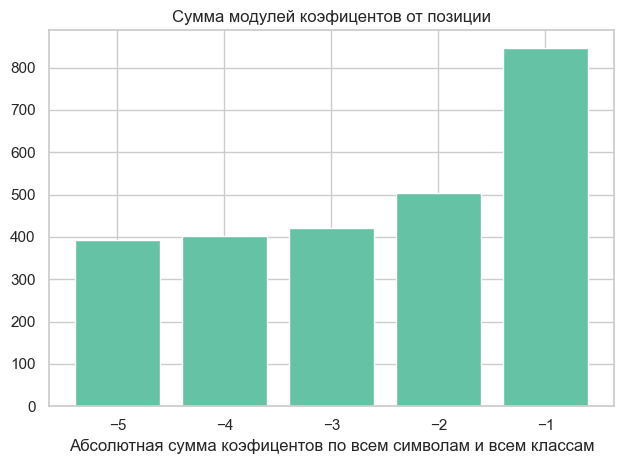

In [208]:
abs_sum = np.zeros((window_size, n_chars))
for i in range(n_chars):
    abs_sum += np.abs(model.coef_[i].reshape(window_size, n_chars))


plt.bar(range(-window_size, 0),abs_sum.sum(axis=1))
plt.title('Сумма модулей коэфицентов от позиции')
plt.xlabel('Позиция в окне')
plt.xlabel('Абсолютная сумма коэфицентов по всем символам и всем классам')
plt.tight_layout()

**Выводы:**

Модель с контекстом по буквам и без механизма внимания дает слабый результат. Общего смысла нет и почти все слова не осмысленные, их просто нет в русском языке. Также явно виден перевес в сторону последних позиций контекста

---
### Задача 2.

#### 1. От one-hot к смыслам: эмбеддинги слов

Мы переходим от предсказания букв к предсказанию целых слов!

Загрузим предобученную модель эмбеддингов **Navec** от проекта Natasha. Эти векторы были обучены на огромном корпусе текстов. В процессе обучения перебирались различные тексты и векторы слов, которые часто встречаются рядом, передвигались ближе друг к другу в многомерном пространстве.

Мы будем использовать версию `hudlit`, которая обучалась на русской художественной литературе.

Каждое слово в Navec — это вектор из 300 чисел.

In [209]:
navec_url = (
    "https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar"
)
navec_path = "navec_hudlit_v1_12B_500K_300d_100q.tar"
if not os.path.exists(navec_path):
    urllib.request.urlretrieve(navec_url, navec_path)

Загрузим модель и убедимся, что вектор слова `солнце` действительно содержит 300 чисел:

In [231]:
navec = Navec.load(navec_path)
navec["солнце"].shape

(300,)

Напишите функцию, которая принимает вектор целевого слова и возвращает $K$ самых близких к нему слов из заданного списка `vocab`. 

Меру близости мы будем оценивать через косинусное расстояние (по сути, это скалярное произведение нормированных векторов). Чем ближе косинус угла между векторами к 1, тем больше похож их смысл.

In [211]:
vocab = [
    "любовь", "сердце", "душа", "мечта", "судьба", "небо",
    "звезда", "ветер", "туман", "море", "ночь", "луна", "солнце",
    "закат", "рассвет", "тоска", "печаль", "радость", "счастье",
    "жизнь", "береза", "поле", "дорога", "тьма", "мгла",
]


def cosine_similarity(v1: np.ndarray, v2: np.ndarray) -> float:
    """Вычисляет косинусное сходство между двумя числовыми векторами.
    :param v1: Первый вектор (numpy массив).
    :param v2: Второй вектор (numpy массив).
    :return: Значение косинусного сходства (от -1.0 до 1.0)."""

    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

In [238]:
def find_nearest_in_vocab(word: str, vocab: list[str], k: int = 3) -> list[tuple[str, float]]:
    """Находит k ближайших слов к заданному слову из словаря на основе косинусного сходства.
    :param word: Целевое слово для поиска ближайших по смыслу слов.
    :param vocab: Список слов (словарь), среди которых ведется поиск.
    :param k: Количество возвращаемых ближайших соседей.
    :return: Список кортежей вида (слово, косинусное сходство), отсортированный по убыванию."""
    list_of_sim = []
    for voc_word in vocab:
        list_of_sim.append((voc_word, cosine_similarity(navec[word], navec[voc_word])))

    list_of_sim.sort(key=(lambda x: x[1]), reverse=True)

    # Найдите k наиболее близких слов к слову word из словаря vocab.
    # Верните эти слова и расстояния в формате [(слово, расстояние), ...]
    return list_of_sim[:k]

Давайте проверим, как наша модель понимает смыслы

In [239]:
test_words = ["сердце", "солнце", "тьма"]

for word in test_words:
    print(f"Ближайшие к слову {word}:")
    print(find_nearest_in_vocab(word, vocab))

Ближайшие к слову сердце:
[('сердце', np.float32(1.0)), ('душа', np.float32(0.49851114)), ('любовь', np.float32(0.4197443))]
Ближайшие к слову солнце:
[('солнце', np.float32(1.0000001)), ('луна', np.float32(0.61312574)), ('небо', np.float32(0.6014561))]
Ближайшие к слову тьма:
[('тьма', np.float32(1.0000001)), ('мгла', np.float32(0.7252577)), ('туман', np.float32(0.5133756))]


Модель реально выводит похожие слова

#### 2. Механизм Внимания (Self-Attention)

Как объяснить модели, на какое слово в контексте смотреть прямо сейчас? На самом деле Attention — это в некотором смысле "мягкий KNN"

Вместо того чтобы жестко выбирать $K$ соседей, назначая им вес 1, а остальным 0, мы берем все слова в контексте, но каждому выдаем свой "вес важности" (от 0 до 1).

> **Принцип работы**
> 
> Пусть у нас есть текущее слово-запрос $q$ и остальные слова $v_j, j\in C$ в контексте $C$ (окно). В нашей общажной модели всё это — векторы-эмбеддинги из Navec.
> 
> 1. С помощью скалярного произведения оцениваем, насколько запрос $q$ близок по смыслу к каждому слову $v_j$ в окне:
>    $$s_j = q^T  v_j$$
>    
>     *Смысл: чем ближе векторы по направлению (по смыслу), тем больше будет это число.*
> 
> 
> 2. Чтобы превратить "сырые" числа в проценты (в сумме дающие 1.0), прогоняем их через Softmax с температурой $T$, получая тем самым веса Attention:
>    $$\alpha_j = \frac{ \exp\left({\left.s_j \right/ T}\right)}{\sum_{j} \exp\left({\left.s_j \right/ T}\right)}$$
> 
> 
> 3. Итоговый вектор контекста $C$ — это взвешенная сумма векторов всех слов в этом контексте:
>    $$u_c = \sum_{j} \alpha_j v_j$$
> 
>     *Итог: получается новый вектор $u_c$, впитавший смыслы всего контекста пропорционально их важности!*


Реализуйте функцию Softmax с параметром температуры.

*Совет*: для вычислительной стабильности перед применением экспоненты вычтите из массива максимальное значение `x := x - max(x)`. Это спасет от переполнения при возведении $e$ в огромную степень, а результат после нормировки останется математически идентичным.

In [241]:
def softmax(x: np.ndarray | list[float], temperature: float = 1.0) -> np.ndarray:
    """Вычисляет функцию Softmax с применением температуры для массива значений.
    :param x: Массив сырых значений (логитов).
    :param temperature: Температура сглаживания распределения (по умолчанию 1.0).
    :return: Массив вероятностей, сумма которых равна 1.0."""
    x -= max(x)
    return np.exp(x / temperature) / np.sum(np.exp(x / temperature))

Допустим, у нас есть фраза: *"они сошлись волна и камень стихи и проза лед и пламень"*. Как слова обращают внимание друг на друга? 

Принцип Self-Attention в самом базовом виде работает следующим образом. 
Мы берем векторы всех слов и считаем скалярное произведение каждого слова с каждым. Это наша матрица "сырой похожести". В формулах Трансформера это шаг $Q K^T$ (где Query и Key — это одни и те же слова нашего предложения). Затем применяем функцию Softmax к каждой строке этой матрицы. Она превращает сырые числа в веса внимания (от 0.0 до 1.0).

*Замечание.* На самом деле $Q,K$ – это разные линейные проекции одних и тех же входных векторов слов. То есть слова в предложении одни и те же, но каждое из них представлено двумя разными векторами: "что я ищу" (вектор query) и "что я могу предложить" (key).

Давайте посчитаем это и нарисуем!



(11, 11)


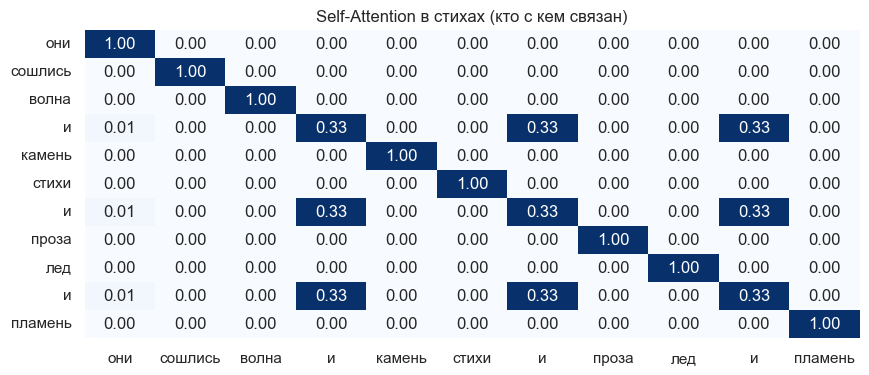

In [246]:
sentence = "они сошлись волна и камень стихи и проза лед и пламень"
words = sentence.split()

# Получаем векторы слов
vecs = np.array([navec[word] for word in words])

# Матрица попарных скалярных произведений
# Это показывает, насколько "похожи" векторы слов друг на друга
scores = vecs @ vecs.T
print(scores.shape)
# Применяем Softmax
attention_matrix = np.apply_along_axis(softmax, 1, scores)

plt.figure(figsize=(10, 4))
sns.heatmap(
    attention_matrix,
    xticklabels=words,
    yticklabels=words,
    annot=True,
    fmt=".2f",
    vmax=0.2,
    cmap="Blues",
    cbar=False,
)
plt.title("Self-Attention в стихах (кто с кем связан)")
plt.yticks(rotation=0)
plt.show()

Кажется, мы увидели не то, что ожидали. Мы видим единичную матрицу (с точностью до повторяющихся слов). Наша модель стала эгоисткой — каждое слово смотрит на 99.9% только на само себя, игнорируя весь остальной контекст....

Все дело в проклятии размерности. Эмбеддинги имеют длину 300 чисел. Когда мы умножаем вектор сам на себя скалярно ($v_1^T v_1$), число получается огромным (например, 20 или 30). А скалярное произведение с другим, даже близким по смыслу словом ($v_1^T v_2$), получается сильно меньше (например, 2 или 5). 

Когда эти числа попадают в экспоненту внутри Softmax, разница становится огромной: $e^{30}$ против $e^5$. Функция Softmax делает из самого большого числа абсолютную единицу `1.0`, а всё остальное просто зануляет.

Именно поэтому авторы статьи "Attention is All You Need" придумали **Scaled Dot-Product Attention** &mdash; деление всех значений на корень из размерности вектора перед применением Softmax. Размерность у нас 300, получаем $\sqrt{300} \approx 17.3$.

В нашей функции `softmax` уже есть параметр `temperature`, который делает ровно это. Добавьте `temperature=20.0`, чтобы сгладить распределение и заставить слова смотреть по сторонам!

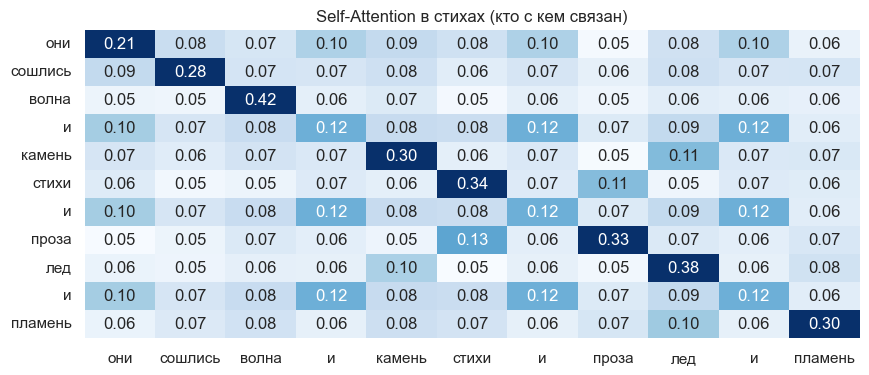

In [248]:
attention_matrix = np.apply_along_axis(lambda x : softmax(x, temperature=20.0), 1, scores)

plt.figure(figsize=(10, 4))
sns.heatmap(
    attention_matrix,
    xticklabels=words,
    yticklabels=words,
    annot=True,
    fmt=".2f",
    vmax=0.2,
    cmap="Blues",
    cbar=False,
)
plt.title("Self-Attention в стихах (кто с кем связан)")
plt.yticks(rotation=0)
plt.show()

Посмотрите на новый график. Какие слова (кроме самих себя) оказались сильно связаны между собой по смыслу в понимании модели?

Теперь модель стала менее эгоистичной.
Наиболее близкие по смыслу слова:
* `и`, `они`
*  `стихи`, `проза`
*  `лед`, `камень`

Это соответствует русскому языку, слова реально достаточно близки

#### 3. Собираем всё вместе: языковая модель на основе Attention

Сам по себе механизм Attention не умеет предсказывать следующее слово. Он лишь создает идеальное математическое представление контекста — вектор контекста.  Это просто взвешенная сумма векторов слов контекста, где весами выступают те самые вероятности из матрицы Attention. 
Получив этот супер-информативный вектор, мы передадим его в нашу обычную логистическую регрессию для классификации (предсказания следующего слова). Примерно так работают слои `Linear + Softmax` в конце архитектуры GPT!

Для начала, ограничим наш словарь. Предсказывать все уникальные слова из стихов для логистической регрессии будет сложно, поскольку классов будут десятки тысяч. Оставим только те слова, которые встречаются хотя бы 10 раз. Редкие слова предсказывать не будем.

In [249]:
min_count = 10  # Задаем порог: слово должно встретиться минимум N раз
window_size = 4  # количество предыдущих слов, на основе которых будем предсказывать следующее

In [250]:
# Собираем все слова в один список
all_words = []
for text in data_sample["text"]:
    all_words.extend(text.split())

# Считаем, сколько раз встречается каждое слово
counts = Counter(all_words)

# Оставляем только частые слова для предсказания
vocab_words = [word for word, count in counts.items() if count >= min_count]

# Создаем  word_to_idx только для частых слов
# Это будет наш список классов для классификации
word_to_idx = {word: i for i, word in enumerate(vocab_words)}

print(f"Всего слов в текстах: {len(counts)}")
print(f"Осталось слов после фильтрации (размер словаря): {len(word_to_idx)}")

Всего слов в текстах: 93551
Осталось слов после фильтрации (размер словаря): 7167


Теперь соберем наш датасет для регрессии следующим образом.
1. Идем по тексту "окном" из 4 слов. Целевая метка $Y$ — 5-е слово.
2. Берем эмбеддинги этих 4 слов из Navec.
3. Слово, которое стоит прямо перед пропуском, будет нашим "запросом" (query). Мы хотим понять: *с учетом этого последнего слова, на что еще в контексте нужно обратить внимание?*
4. Считаем скалярные произведения query со всеми словами в окне.
5. Применяем Softmax с температурой 20, получая тем самым веса Attention.
6. Умножаем матрицу векторов на эти веса — получаем единый кектор контекста. Это и будут наши признаки $X$.

In [253]:
X_attn = []
y_words = []

for text_string in tqdm(data_sample["text"]):
    words = text_string.split()

    if len(words) <= window_size:
        continue

    for i in range(len(words) - window_size):
        context = words[i : i + window_size]
        target = words[i + window_size]

        # Целевое слово должно быть популярным (быть в нашем новом словаре)
        if target not in word_to_idx:
            # Пропускаем, не будем учить модель предсказывать редкое слово
            continue

        # Слова контекста должны быть известны Navec (чтобы взять векторы)
        try:
            vecs = np.array([navec[w] for w in context])
        except KeyError:
            # Если хоть одно слово неизвестно Navec - пропускаем
            continue

        # Посчитайте вектор Attention
        query = vecs[-1]
        scores = vecs @ query
        context_vector = softmax(scores, temperature=20.0) @ vecs

        X_attn.append(context_vector)
        y_words.append(word_to_idx[target])

X_attn = np.array(X_attn)
y_words = np.array(y_words)

print(f"Итоговая размерность X: {X_attn.shape}")
print(f"Итоговая размерность y: {y_words.shape}")

  0%|          | 0/5000 [00:00<?, ?it/s]

Итоговая размерность X: (390765, 300)
Итоговая размерность y: (390765,)


Матрица признаков имеет размер `(n, 300)`, то есть мы сжали 4 слова в один вектор размером 300 чисел. Но благодаря Attention, в отличие от простого усреднения, этот вектор динамически подчеркнул самые важные по смыслу слова.

Теперь обучим логистическую регрессию предсказывать индекс следующего слова по этому вектору контекста.

In [256]:
model = SGDClassifier(loss='log_loss')
model.fit(X_attn, y_words)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'log_loss'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


Финальный штрих. Напишем функцию генерации текста, которая будет использовать нашу обученную Attention-модель.

Процесс генерации на каждом шаге выглядит следующим образом.
1. Берем последние 4 слова текста и достаем их эмбеддинги.
2. Вычисляем вектор контекста.
3. Передаем его в логистическую регрессию для предсказания вероятностей.
4. Применяем температуру сэмплирования к вероятностям и выбираем следующее слово.

Допишите недостающие части кода в функции.

In [276]:
def generate_with_attention(
    seed_words: list[str], length: int = 10, temperature: float = 1.0
) -> str:
    """Генерирует текст по словам, используя механизм Attention и логистическую регрессию.
    :param seed_words: Список начальных слов для старта генерации.
    :param length: Количество слов для генерации.
    :param temperature: Температура для генерации.
    :return: Итоговая сгенерированная строка текста."""

    current_words = seed_words.copy()

    # Создадим обратный словарь
    idx_to_word = {i: w for w, i in word_to_idx.items()}

    for _ in range(length):
        # Контекст
        context = current_words[-window_size:]

        # Если слово незнакомо, берем нулевой вектор
        vecs = np.array([navec[w] if w in navec else np.zeros(300) for w in context])

        # Механизм Внимания (как раньше)
        query = vecs[-1]
        scores = vecs @ query
        context_vector = softmax(scores, temperature=20.0) @ vecs  # здесь temperature=20, это не температура генерации!

        # Выполните оценку вероятностей, примените температуру и сгенерируйте следующее слово
        probabilities = model.predict_proba(np.array(context_vector).reshape(1, -1))

        proba_t = (probabilities ** (1 / temperature) / np.sum(probabilities ** (1 / temperature)))[0]

        next_word_idx = np.random.choice(model.classes_, p=proba_t)

        next_word = idx_to_word[next_word_idx]
        current_words.append(next_word)

    return " ".join(current_words)

Барабанная дробь! Запускаем нашу GPT-0.001.

In [277]:
# Параметры генерации
length = 20
temperatures = [0.5, 1.0, 2.0]

examples = ["буря мглою небо кроет", "белеет парус одинокий в тумане моря"]


for i, text in enumerate(examples, 1):
    seed_words = text.split()
    for temp in temperatures:
        result = generate_with_attention(seed_words, length=length, temperature=temp)
        print(f"T={temp}: {result}")

T=0.5: буря мглою небо кроет над над нами нами нами как и в в душе моей моей твоей твоей твоей твоей и твоей мне я
T=1.0: буря мглою небо кроет на простор давно и свет этой я самое глаз правда и давно тут видел могу но я твои слова больше
T=2.0: буря мглою небо кроет во дни то свой смотреть такой старик ждет им убить тут был твоим что опять новые же свободу лишь лучах
T=0.5: белеет парус одинокий в тумане моря в них в этом мире не что есть что я в нем в нем день раз в день день день
T=1.0: белеет парус одинокий в тумане моря с стороны кошки перед тобой мною цветы в мои дал сей свой час твой мысль смерти на ты над ними
T=2.0: белеет парус одинокий в тумане моря до встал средь друзья же усмешкой дыхание ветра мы потерял под смелый каких не собой только волны идет чуть три


Оцените результат:
* Насколько осмысленными получаются генерации по сравнению с посимвольной моделью из первой части?
* Удается ли модели сохранять тему заданных стартовых слов?
* Что можно было бы улучшить в нашей "общажной" модели, если бы у нас было больше вычислительных мощностей?

* Генерация получается намного более качественной по сравнению с посимвольной т.к. теперь каждое слово точно существует и текст перестает выглядеть как случайный набор букв
* Модели с переменным успехом получается сохранять тему заданных в начале слов. Возможно тематика близкая, но из-за того, что текст все-таки не очень осмысленный, то сложно оценить это
* Можно бы было увеличить размер контекстного окна и увеличить кол-во угадываемых слов. Тогда модель бы рассматривала более широкий контекст и выдавала бы более разнообразный текст. Также можно бы было сделать согласование слов, т. е. чтобы слова были связаны по числу, падежу, времени, роду и т. д.
* Если говорить про температуру, то при $T=0.5$ текст зацикливается в словах, слишком мало случайности, при $T=1$ и $T=2$ ситуация намного лучше, текст более разнообразный

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для ВвАД